# 5. Backtesting

This notebook backtests the **2025 portfolio** as actually traded and then asks a
counterfactual question: how would the **2026 portfolio** have performed across
the same window?

Scope is **UK financial year 2025-26 (05-Apr-2025 → 04-Apr-2026)**. Live forward
P&L for the 2026 portfolio (with the 12-Apr-2026 InvestEngine + Trading212
rebalances) lives in [`04_performance_tracking.ipynb`](04_performance_tracking.ipynb).

In [1]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path("..").resolve()))

from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from etf_utils.config import RISK_FREE_RATE, PROJECT_ROOT
from etf_utils.data_provider import DataProvider
from etf_utils.database import (
    load_portfolio,
    save_rebalancing_trades,
    load_rebalancing_trades,
)
from etf_utils.backtesting import (
    Backtester,
    parse_investengine_statement,
    dynamic_portfolio_return,
    rolling_avg_pairwise_corr,
    rolling_constituent_beta,
    period_metrics_table,
)
from etf_utils.metrics import (
    calculate_beta,
    calculate_information_ratio,
    calculate_max_drawdown,
    calculate_sharpe_ratio,
    calculate_tracking_error,
    rolling_sharpe,
    rolling_volatility_from_cumret,
)

# UK financial-year 2025-26 — the window every section in this notebook uses.
FY25_START = pd.Timestamp("2025-04-05")
FY25_END   = pd.Timestamp("2026-04-04")
FY25_BDAYS = len(pd.bdate_range(FY25_START, FY25_END))

provider = DataProvider()
portfolio_25 = load_portfolio(year=2025)
print(f"Loaded 2025 portfolio: {len(portfolio_25)} positions, "
      f"{portfolio_25['asset_class'].nunique()} asset classes.")
print(f"Backtest window: {FY25_START.date()} → {FY25_END.date()} "
      f"({FY25_BDAYS} business days).")


Loaded 2025 portfolio: 16 positions, 2 asset classes.
Backtest window: 2025-04-05 → 2026-04-04 (260 business days).


## 1. 2025 Actual Portfolio Backtest

Parses the InvestEngine trading statement to compute a Time-Weighted Return
that explicitly accounts for actual rebalancing cash-flows. Compares against
two counterfactuals — a true Buy & Hold (zero rebalances) and a synthetic 2×
frequency strategy — and finishes with a professional metrics block against
a fixed-weight blended benchmark.


### 1.1 Trade Loading & Backtester Setup


In [2]:
statement_path = (
    PROJECT_ROOT / "data" / "investment_statements" / "RebalancingTrades2025.csv"
)

if statement_path.exists():
    trades = parse_investengine_statement(statement_path)
    save_rebalancing_trades(trades, portfolio_year=2025)
    print(f"Parsed {len(trades)} trades from CSV and saved to DB.")
else:
    trades = load_rebalancing_trades(portfolio_year=2025)
    if trades.empty:
        raise FileNotFoundError(
            f"No trading statement at {statement_path} and no trades in DB "
            f"for year 2025."
        )
    trades["trade_date"] = pd.to_datetime(trades["trade_date"])
    print(f"Loaded {len(trades)} trades from DB.")

print(f"Date range: {trades['trade_date'].min().date()} → "
      f"{trades['trade_date'].max().date()}")
print(f"Tickers: {trades['ticker'].nunique()}")

bt = Backtester.from_trades(trades, provider, end_date=FY25_END)
price_data = bt.price_data
all_tickers = sorted(price_data.keys())
rebalance_dates = sorted(trades["trade_date"].unique())
first_trade_date = bt.start_date

# Per-ticker share ledger and cost basis (used downstream)
share_ledger = defaultdict(float)
cost_basis = defaultdict(float)
for _, t in trades.iterrows():
    share_ledger[t["ticker"]] += t["signed_qty"]
    cost_basis[t["ticker"]] += t["signed_value"]
print(f"Share ledger built for {len(share_ledger)} tickers.")


Parsed 351 trades from CSV and saved to DB.
Date range: 2025-05-12 → 2026-03-23
Tickers: 16


Share ledger built for 16 tickers.


### 1.2 Individual Ticker Performance

Each ETF's pure adjusted-close price return over FY25 vs the personal
money-weighted return based on actual shares bought and sold.


In [3]:
first_day_trades = trades[trades["trade_date"] == first_trade_date]
initial_deposits = {}
for _, t in first_day_trades.iterrows():
    initial_deposits[t["ticker"]] = (
        initial_deposits.get(t["ticker"], 0) + t["signed_value"]
    )
total_initial_cash = sum(v for v in initial_deposits.values() if v > 0)

ticker_rows = []
for ticker in all_tickers:
    df = price_data[ticker]
    after_start = df[df.index >= first_trade_date]
    before_end = df[df.index <= FY25_END]
    if after_start.empty or before_end.empty:
        continue
    px_start = float(after_start["close"].iloc[0])
    px_end = float(before_end["close"].iloc[-1])
    price_ret = ((px_end / px_start) - 1) * 100

    net_cost = cost_basis.get(ticker, 0)
    shares = share_ledger.get(ticker, 0)
    current_val = shares * px_end if shares > 0 else 0
    my_ret = ((current_val - net_cost) / net_cost * 100) if net_cost > 0 else 0
    first_px = trades[trades["ticker"] == ticker].iloc[0]["price"]
    weight = (
        (initial_deposits.get(ticker, 0) / total_initial_cash * 100)
        if total_initial_cash > 0 else 0
    )

    ticker_rows.append({
        "Ticker": ticker,
        "Start": after_start.index[0].date(),
        "End": before_end.index[-1].date(),
        "Trade Px (£)": round(first_px, 2),
        "DP Start": round(px_start, 2),
        "DP End": round(px_end, 2),
        "Price Ret (%)": round(price_ret, 2),
        "My Ret (%)": round(my_ret, 2),
        "Weight (%)": round(weight, 1),
    })

display(pd.DataFrame(ticker_rows))


,Ticker,Start,End,Trade Px (£),DP Start,DP End,Price Ret (%),My Ret (%),Weight (%)
0,AUAD,2025-05-12,2026-04-02,18.39,17.79,20.62,15.91,12.40,16.0
1,EMCP,2025-05-12,2026-04-02,68.33,63.67,67.32,5.73,-1.07,1.0
2,HMCH,2025-05-12,2026-04-02,5.69,5.56,5.79,4.07,1.47,2.0
3,IBZL,2025-05-12,2026-04-02,16.84,15.72,23.48,49.42,48.14,8.0
4,IGLT,2025-05-12,2026-04-02,9.98,9.56,9.82,2.72,-1.54,1.0
5,IMIB,2025-05-12,2026-04-02,20.43,19.61,24.14,23.13,18.25,18.0
6,LCUK,2025-05-12,2026-04-02,12.16,12.19,14.55,19.41,19.82,9.0
7,PRIJ,2025-05-12,2026-04-02,24.12,24.17,29.02,20.07,21.68,7.0
8,PRIR,2025-05-12,2026-04-02,14.52,14.12,14.70,4.16,0.98,3.0
9,QYLP,2025-05-12,2026-04-02,11.94,10.69,12.17,13.81,1.95,7.0


### 1.3 Portfolio Summary: TWR vs MWR

**Time-Weighted Return** chains sub-period returns across rebalancing events
and is the standard for measuring strategy performance independent of
cash-flow timing. **Money-Weighted Return** reflects personal experience,
including how well-timed deposits were.


In [4]:
actual_twr_series = bt.run_twr_series(trades)
total_twr = actual_twr_series.iloc[-1]

CASH_DEPOSITED = 20_000
total_trade_cost = sum(cost_basis.values())
estimated_dividends_reinvested = total_trade_cost - CASH_DEPOSITED

def _value_at(date):
    val = 0.0
    for t, shares in share_ledger.items():
        px = bt.get_price(t, date)
        if px:
            val += shares * px
    return val

total_current_value = _value_at(FY25_END)
mwr_return = (total_current_value / CASH_DEPOSITED - 1) * 100

summary_df = pd.DataFrame({
    "Metric": [
        "Time-Weighted Return (TWR)",
        "Money-Weighted Return (MWR)",
        "Net Cash Deposited",
        "Dividends Reinvested (est.)",
        "Portfolio Value @ FY25 End",
        "Absolute P&L (incl. dividends)",
    ],
    "Value": [
        f"{total_twr:.2f}%",
        f"{mwr_return:.2f}%",
        f"£{CASH_DEPOSITED:,.2f}",
        f"£{estimated_dividends_reinvested:,.2f}",
        f"£{total_current_value:,.2f}",
        f"£{total_current_value - CASH_DEPOSITED:,.2f}",
    ],
})
display(summary_df)


,Metric,Value
0,Time-Weighted Return (TWR),15.62%
1,Money-Weighted Return (MWR),15.46%
2,Net Cash Deposited,"£20,000.00"
3,Dividends Reinvested (est.),£760.29
4,Portfolio Value @ FY25 End,"£23,091.60"
5,Absolute P&L (incl. dividends),"£3,091.60"


### 1.3.1 Rebalancing Impact: Buy & Hold Counterfactual

What would Day 1's investment be worth at FY25 end if no further trading
or rebalancing was ever done? Comparing this to the actual TWR isolates
whether the rebalancing schedule added or destroyed value.


In [5]:
bnh_cost = 0
bnh_ticker_cost = {}
bnh_holdings = {}
for _, t in first_day_trades.iterrows():
    bnh_cost += t["signed_value"]
    bnh_ticker_cost[t["ticker"]] = (
        bnh_ticker_cost.get(t["ticker"], 0) + t["signed_value"]
    )
    bnh_holdings[t["ticker"]] = (
        bnh_holdings.get(t["ticker"], 0) + t["signed_qty"]
    )

bnh_series = bt.run_buy_and_hold_series(bnh_holdings)
bnh_total_return = bnh_series.iloc[-1]

bnh_price_only_val = 0
ticker_stats = []
for tkr, qty in bnh_holdings.items():
    px_start = bt.get_price(tkr, first_trade_date)
    px_end = bt.get_price(tkr, FY25_END)
    if px_start and px_end:
        bnh_price_only_val += qty * px_end
        ticker_stats.append({
            "Ticker": tkr,
            "Adj Start": round(px_start, 2),
            "Adj End": round(px_end, 2),
            "Total Return (%)": round(((px_end / px_start) - 1) * 100, 2),
        })

bnh_price_return = (bnh_price_only_val / bnh_cost - 1) * 100 if bnh_cost > 0 else 0
bnh_implied_dividends = bnh_total_return - bnh_price_return
bnh_estimated_value = bnh_cost * (1 + bnh_total_return / 100)

print("=" * 65)
print("REBALANCING IMPACT: Buy & Hold Counterfactual")
print("=" * 65)
print(f"Initial Investment (Day 1):       £{bnh_cost:,.2f}")
print(f"B&H Price-Only Return:            {bnh_price_return:.2f}%")
print(f"B&H Implied Dividends Reinvested: +{bnh_implied_dividends:.2f}%")
print(f"B&H Total Return (inc. divs):     {bnh_total_return:.2f}%")
print(f"B&H Est. Value (inc. divs):       £{bnh_estimated_value:,.2f}")
print()
print(f"Actual Portfolio Return (TWR):    {total_twr:.2f}%")
diff = total_twr - bnh_total_return
impact = "HELPED" if diff > 0 else "HURT (Drag)"
print(f"Net Rebalancing Impact:           {diff:+.2f}%  ({impact})")

print("\nPer-Ticker Buy & Hold Returns (adjusted for dividends):")
display(pd.DataFrame(ticker_stats).sort_values("Total Return (%)", ascending=False))


REBALANCING IMPACT: Buy & Hold Counterfactual
Initial Investment (Day 1):       £19,988.32
B&H Price-Only Return:            11.67%
B&H Implied Dividends Reinvested: +4.13%
B&H Total Return (inc. divs):     15.81%
B&H Est. Value (inc. divs):       £23,147.65

Actual Portfolio Return (TWR):    15.62%
Net Rebalancing Impact:           -0.19%  (HURT (Drag))

Per-Ticker Buy & Hold Returns (adjusted for dividends):


,Ticker,Adj Start,Adj End,Total Return (%)
2,IBZL,15.72,23.48,49.42
1,IMIB,19.61,24.14,23.13
13,PRIJ,24.17,29.02,20.07
15,LCUK,12.19,14.55,19.41
7,AUAD,17.79,20.62,15.91
14,QYLP,10.69,12.17,13.81
12,VEMT,30.34,32.71,7.83
5,EMCP,63.67,67.32,5.73
0,VECP,39.58,41.70,5.36
9,TRXG,25.64,26.93,5.05


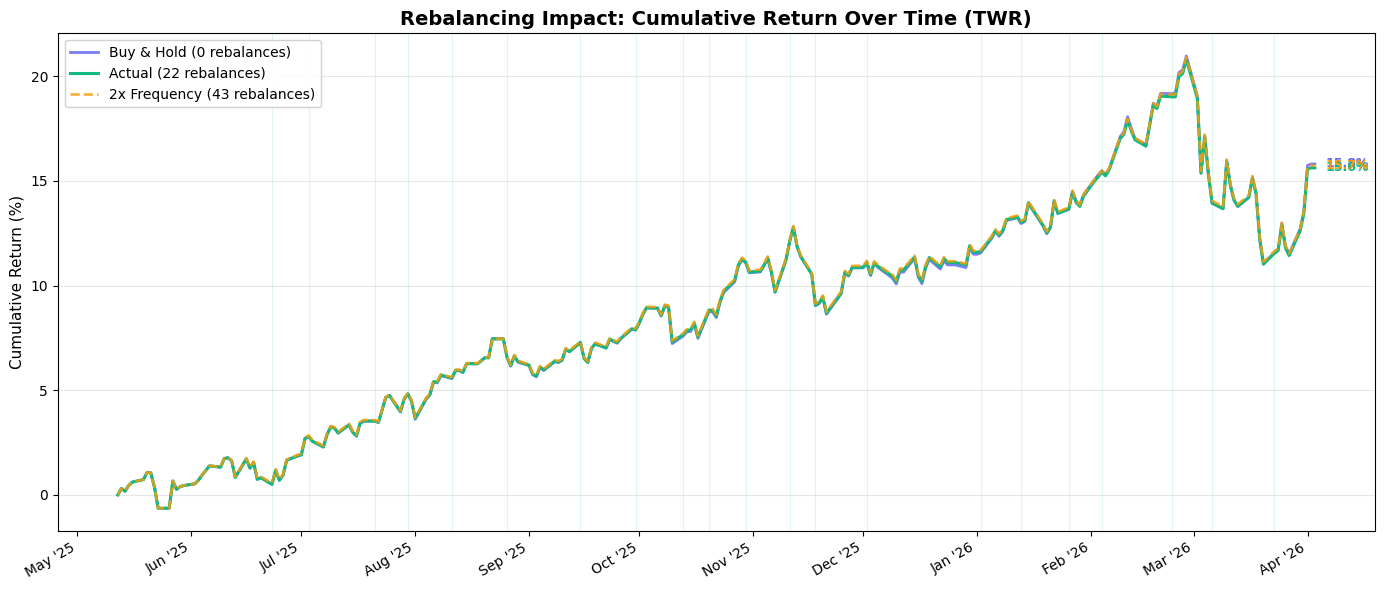


Final Cumulative Returns (TWR):
  Buy & Hold:                     15.81%
  Actual (22 rebalances):    15.62%
  2x Frequency (43 rebal): 15.73%


In [6]:
sorted_rebal = sorted(rebalance_dates)
double_rebal_dates = []
for i in range(len(sorted_rebal)):
    double_rebal_dates.append(sorted_rebal[i])
    if i < len(sorted_rebal) - 1:
        mid = sorted_rebal[i] + (sorted_rebal[i + 1] - sorted_rebal[i]) / 2
        double_rebal_dates.append(mid + pd.tseries.offsets.BDay(0))
double_rebal_dates = sorted(set(double_rebal_dates))

target_weights = {tkr: cost / bnh_cost for tkr, cost in bnh_ticker_cost.items()}
double_twr_series = bt.run_simulated_rebalance(
    bnh_holdings, target_weights, double_rebal_dates
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(bt.all_dates, bnh_series, label="Buy & Hold (0 rebalances)",
        color="#6366f1", linewidth=2, alpha=0.85)
ax.plot(bt.all_dates, actual_twr_series,
        label=f"Actual ({len(sorted_rebal)} rebalances)",
        color="#10b981", linewidth=2.2)
ax.plot(bt.all_dates, double_twr_series,
        label=f"2x Frequency ({len(double_rebal_dates)} rebalances)",
        color="#f59e0b", linewidth=1.8, linestyle="--", alpha=0.85)

for rd in sorted_rebal[1:]:
    ax.axvline(rd, color="#10b981", alpha=0.12, linewidth=0.8)

ax.set_title("Rebalancing Impact: Cumulative Return Over Time (TWR)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Cumulative Return (%)", fontsize=11)
ax.legend(loc="upper left", fontsize=10, framealpha=0.9)
ax.grid(axis="y", alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate(rotation=30)

for label, series, color in [
    ("B&H", bnh_series, "#6366f1"),
    ("Actual", actual_twr_series, "#10b981"),
    ("2x", double_twr_series, "#f59e0b"),
]:
    ax.annotate(f"{series.iloc[-1]:.1f}%", xy=(bt.all_dates[-1], series.iloc[-1]),
                xytext=(8, 0), textcoords="offset points",
                fontsize=9, fontweight="bold", color=color, va="center")

plt.tight_layout()
plt.show()

print(f"\nFinal Cumulative Returns (TWR):")
print(f"  Buy & Hold:                     {bnh_series.iloc[-1]:.2f}%")
print(f"  Actual ({len(sorted_rebal)} rebalances):    {actual_twr_series.iloc[-1]:.2f}%")
print(f"  2x Frequency ({len(double_rebal_dates)} rebal): {double_twr_series.iloc[-1]:.2f}%")


### 1.3.2 Risk & Volatility

30-day rolling annualised volatility across the three strategies. Lower vol
typically means a smoother investor experience for the same end return.


RISK & VOLATILITY SUMMARY (30-Day Rolling Window)


,Strategy,Avg Vol (%),Max 30d Vol (%)
0,Buy & Hold,8.57,18.47
1,Actual (22 rebalances),8.45,18.02
2,2x Frequency (43 rebalances),8.42,18.04


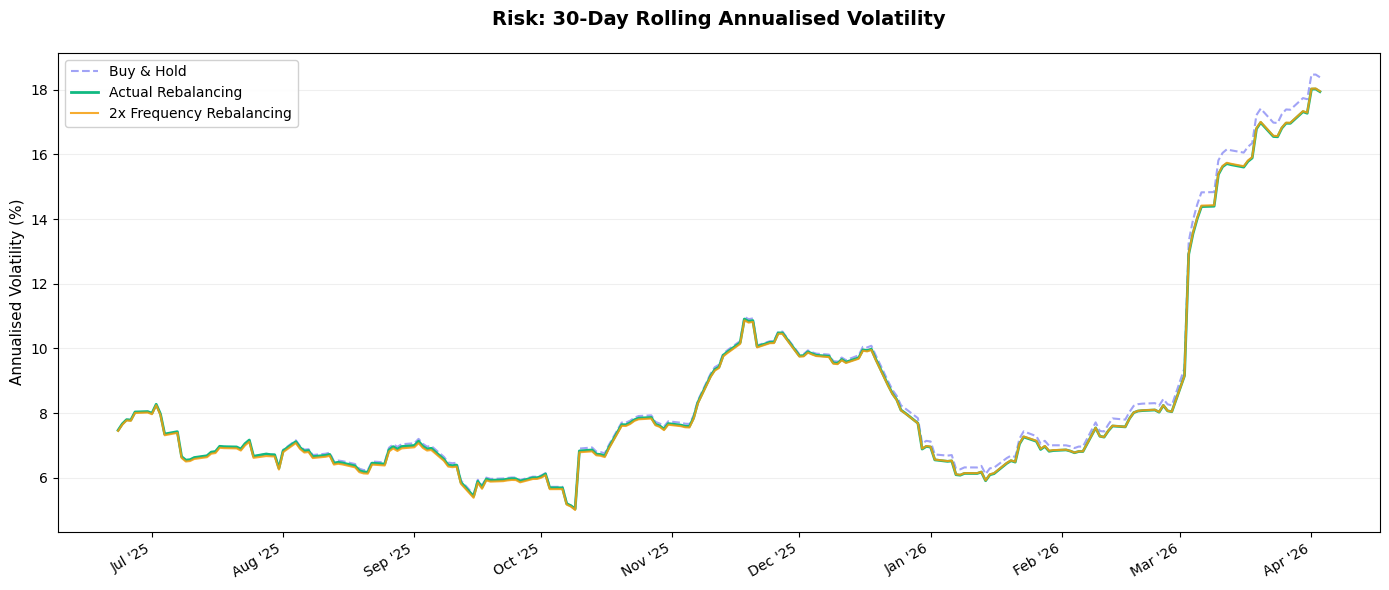

In [7]:
vol_actual = rolling_volatility_from_cumret(actual_twr_series, window=30)
vol_bnh    = rolling_volatility_from_cumret(bnh_series, window=30)
vol_2x     = rolling_volatility_from_cumret(double_twr_series, window=30)

vol_summary = pd.DataFrame({
    "Strategy": [
        "Buy & Hold",
        f"Actual ({len(sorted_rebal)} rebalances)",
        f"2x Frequency ({len(double_rebal_dates)} rebalances)",
    ],
    "Avg Vol (%)": [vol_bnh.mean(), vol_actual.mean(), vol_2x.mean()],
    "Max 30d Vol (%)": [vol_bnh.max(), vol_actual.max(), vol_2x.max()],
}).round(2)
print("RISK & VOLATILITY SUMMARY (30-Day Rolling Window)")
display(vol_summary)

plt.figure(figsize=(14, 6))
plt.plot(bt.all_dates, vol_bnh, label="Buy & Hold", color="#6366f1",
         linestyle="--", alpha=0.6)
plt.plot(bt.all_dates, vol_actual, label="Actual Rebalancing",
         color="#10b981", linewidth=2)
plt.plot(bt.all_dates, vol_2x, label="2x Frequency Rebalancing",
         color="#f59e0b", linewidth=1.5, alpha=0.85)
plt.title("Risk: 30-Day Rolling Annualised Volatility",
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel("Annualised Volatility (%)", fontsize=11)
plt.grid(axis='y', alpha=0.2)
plt.legend(loc="upper left", fontsize=10, framealpha=0.9)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gcf().autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()


### 1.3.3 ETF Correlation Dynamics (2025 Portfolio)

Correlation analysis flags whether diversification is breaking down during
market stress. Spikes toward 1.0 across all assets typically mark systemic
shocks, when traditional diversification offers least benefit.

The milestones below cover tariff shocks of 2025 through to the systemic
shocks of the 2026 SaaSpocalypse and Iran–US conflict.


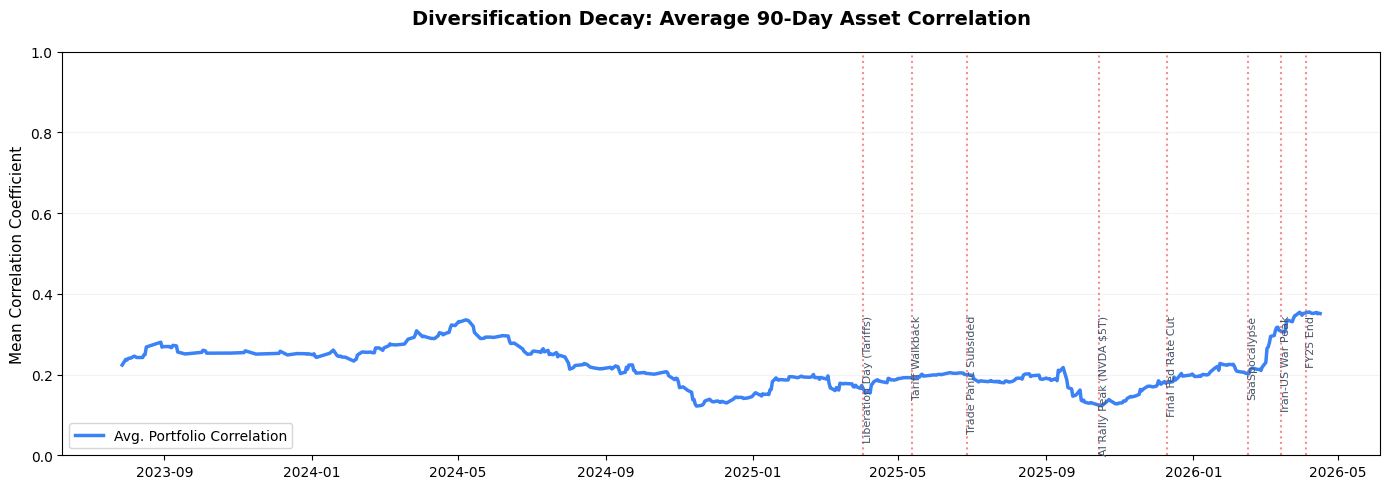

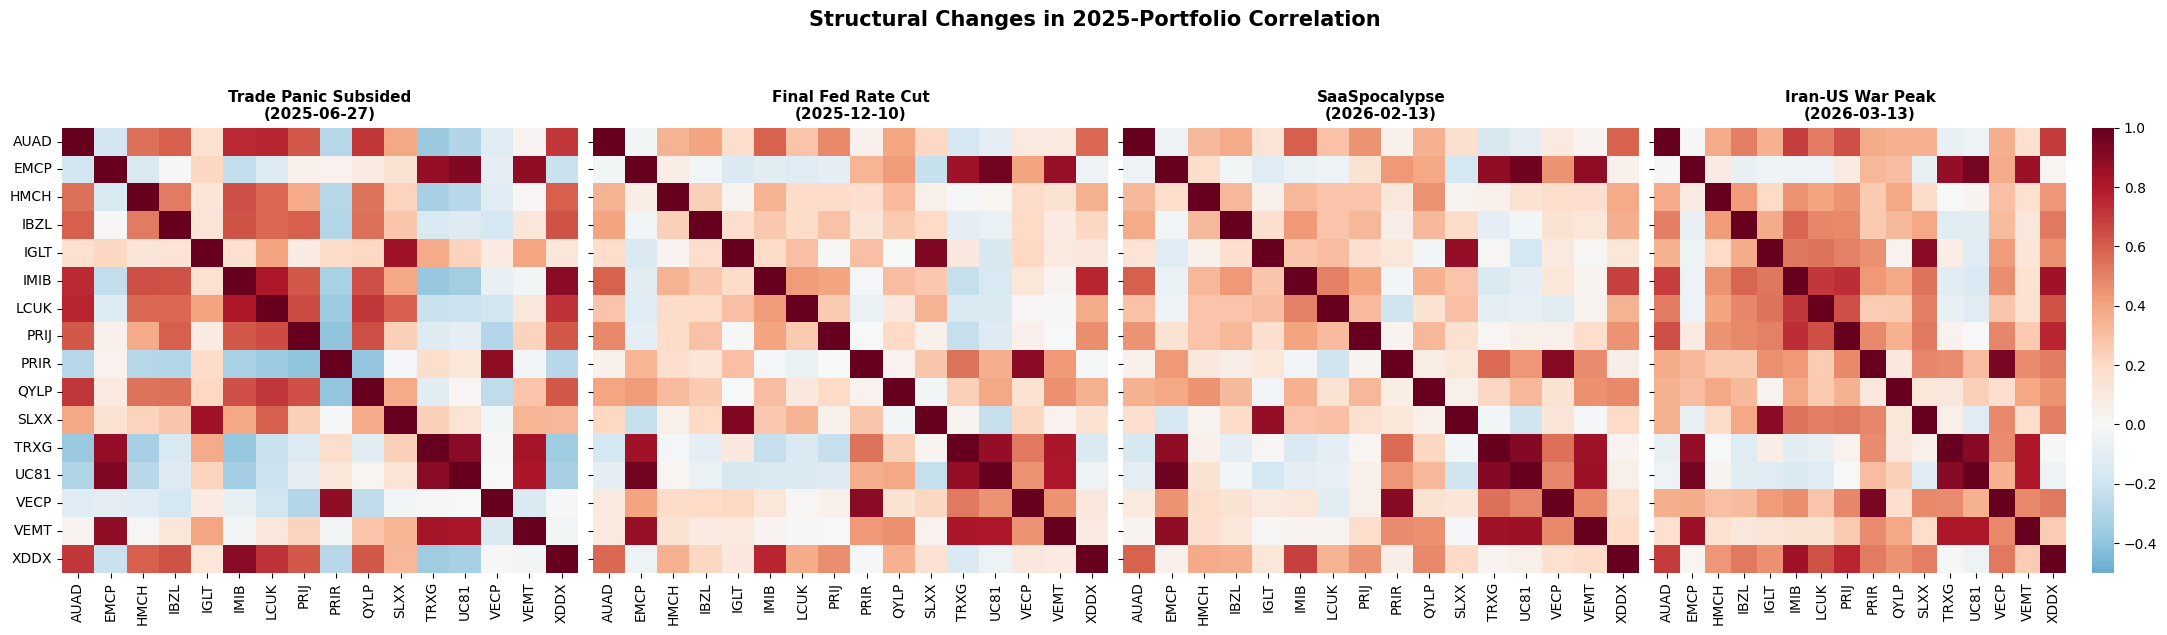

In [8]:
timeline = {
    'Liberation Day (Tariffs)': '2025-04-02',
    'Tariff Walkback': '2025-05-13',
    'Trade Panic Subsided': '2025-06-27',
    'AI Rally Peak (NVDA $5T)': '2025-10-15',
    'Final Fed Rate Cut': '2025-12-10',
    'SaaSpocalypse': '2026-02-15',
    'Iran-US War Peak': '2026-03-15',
    'FY25 End': str(FY25_END.date()),
}
snapshot_events = [
    'Trade Panic Subsided', 'Final Fed Rate Cut',
    'SaaSpocalypse', 'Iran-US War Peak',
]

returns_df_25 = bt.price_df[all_tickers].pct_change().dropna()
rolling_corr = returns_df_25.rolling(window=90).corr()

avg_corr_series = rolling_avg_pairwise_corr(returns_df_25, window=90)

plt.figure(figsize=(14, 5))
plt.plot(avg_corr_series, color='#3b82f6', linewidth=2.5,
         label="Avg. Portfolio Correlation")
for name, date_str in timeline.items():
    dt = pd.to_datetime(date_str)
    if dt >= avg_corr_series.dropna().index.min():
        plt.axvline(dt, color='#ef4444', linestyle=':', alpha=0.6)
        plt.text(dt, plt.ylim()[1] * 0.95, name, rotation=90,
                 verticalalignment='top', fontsize=8, color='#475569')
plt.title("Diversification Decay: Average 90-Day Asset Correlation",
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel("Mean Correlation Coefficient", fontsize=11)
plt.ylim(0, 1.0)
plt.grid(axis='y', alpha=0.15)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

# Snapshot heatmaps at regime-shift dates
fig, axes = plt.subplots(1, len(snapshot_events), figsize=(22, 6))
available_dates = rolling_corr.index.get_level_values(0).unique()
for i, event_name in enumerate(snapshot_events):
    target = pd.to_datetime(timeline[event_name])
    eligible = available_dates[available_dates <= target]
    if len(eligible) == 0:
        axes[i].set_visible(False)
        continue
    nearest = eligible[-1]
    sns.heatmap(rolling_corr.loc[nearest], annot=False, cmap='RdBu_r',
                center=0, vmin=-0.5, vmax=1, ax=axes[i],
                cbar=(i == len(snapshot_events) - 1))
    axes[i].set_title(f"{event_name}\n({nearest.strftime('%Y-%m-%d')})",
                      fontsize=11, fontweight='bold')
    if i > 0:
        axes[i].set_yticklabels([])
plt.suptitle("Structural Changes in 2025-Portfolio Correlation",
             fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


### 1.4 Professional Metrics & Blended Benchmark

Compares the actual TWR against a **65/10/5/10 fixed-weight blended
benchmark** built from the portfolio's own holdings (no-rebalance variant
— a true buy-and-forget basket; see
`Backtester.build_blended_benchmark_no_rebalance`).

TER is **not** subtracted manually: AlphaVantage / yfinance adjusted-close
prices already embed each fund's TER inside its NAV. The reported TWRs are
therefore implicitly net-of-TER. See [Methodology → TER, OCF and
adjusted-close prices](../content/00b_methodology.md#ter-ocf-and-adjusted-close-prices).


In [9]:
total_dep = sum(initial_deposits.values()) if initial_deposits else 0
bench_weights = (
    {t: v / total_dep for t, v in initial_deposits.items()}
    if total_dep > 0 else {}
)

# Per-ticker TER (bps) for disclosure only — already embedded in prices.
ter_bps = {}
try:
    p25 = load_portfolio(year=2025)
    for _, r in p25.iterrows():
        ter_pct = float(r.get("ter", 0) or 0)
        ter_bps[r["ticker"]] = ter_pct * 100
except Exception as exc:
    print(f"TER lookup failed ({exc}); weighted-average TER will be 0.")

weighted_avg_ter_bps = sum(
    bench_weights.get(t, 0) * ter_bps.get(t, 0) for t in bench_weights
)

blended_bench = bt.build_blended_benchmark_no_rebalance(bench_weights)

aligned = pd.concat(
    [actual_twr_series.rename("portfolio"), blended_bench.rename("benchmark")],
    axis=1, join="inner",
).dropna()

port_daily = (1 + aligned["portfolio"] / 100).pct_change().dropna()
bench_daily = (1 + aligned["benchmark"] / 100).pct_change().dropna()

ann_ret_port = (1 + port_daily.mean()) ** 252 - 1
ann_vol_port = float(port_daily.std() * np.sqrt(252))
sharpe_port = calculate_sharpe_ratio(ann_ret_port, ann_vol_port)
ann_ret_bench = (1 + bench_daily.mean()) ** 252 - 1
ann_vol_bench = float(bench_daily.std() * np.sqrt(252))
sharpe_bench = calculate_sharpe_ratio(ann_ret_bench, ann_vol_bench)

mdd_port = calculate_max_drawdown(1 + aligned["portfolio"] / 100)
mdd_bench = calculate_max_drawdown(1 + aligned["benchmark"] / 100)
beta = calculate_beta(port_daily, bench_daily)
te = calculate_tracking_error(port_daily, bench_daily)
ir = calculate_information_ratio(port_daily, bench_daily)

def _fmt_pct(x): return f"{x*100:+.2f}%" if pd.notna(x) else "—"
def _fmt_num(x, nd=2): return f"{x:.{nd}f}" if pd.notna(x) else "—"

print("=" * 78)
print("  Professional Metrics — Portfolio vs 65/10/5/10 Blended Benchmark")
print("=" * 78)
print(f"  Risk-free rate (config):          {RISK_FREE_RATE:.2%}")
print(f"  Weighted-avg TER (disclosure):    {weighted_avg_ter_bps:.1f} bps  "
      f"(already embedded in prices)")
print("-" * 78)
print(f"  {'':30s}  {'Portfolio':>14s}   {'Benchmark':>14s}")
print(f"  {'TWR final (net of TER)':30s}  "
      f"{_fmt_num(actual_twr_series.iloc[-1]):>13s}%  "
      f"{_fmt_num(blended_bench.iloc[-1]):>13s}%")
print(f"  {'Annualised return':30s}  {_fmt_pct(ann_ret_port):>14s}   "
      f"{_fmt_pct(ann_ret_bench):>14s}")
print(f"  {'Annualised volatility':30s}  {_fmt_pct(ann_vol_port):>14s}   "
      f"{_fmt_pct(ann_vol_bench):>14s}")
print(f"  {'Sharpe ratio':30s}  {_fmt_num(sharpe_port):>14s}   "
      f"{_fmt_num(sharpe_bench):>14s}")
print(f"  {'Max drawdown':30s}  {_fmt_pct(mdd_port['value']):>14s}   "
      f"{_fmt_pct(mdd_bench['value']):>14s}")
print(f"  {'   peak → trough':30s}  "
      f"{mdd_port['peak_date'].date()} → {mdd_port['trough_date'].date()}")
print(f"  {'Beta (port vs blended)':30s}  {_fmt_num(beta):>14s}")
print(f"  {'Tracking error (annualised)':30s}  {_fmt_pct(te):>14s}")
print(f"  {'Information Ratio':30s}  {_fmt_num(ir):>14s}")
print("=" * 78)


  Professional Metrics — Portfolio vs 65/10/5/10 Blended Benchmark
  Risk-free rate (config):          4.00%
  Weighted-avg TER (disclosure):    26.8 bps  (already embedded in prices)
------------------------------------------------------------------------------
                                       Portfolio        Benchmark
  TWR final (net of TER)                  15.62%          15.89%
  Annualised return                      +17.44%          +17.76%
  Annualised volatility                   +9.49%           +9.62%
  Sharpe ratio                              1.42             1.43
  Max drawdown                            -8.10%           -8.16%
     peak → trough                2026-02-27 → 2026-03-20
  Beta (port vs blended)                    0.99
  Tracking error (annualised)             +0.27%
  Information Ratio                        -0.97


### 1.5 2025 Portfolio Holdings @ FY25 End

Snapshot of the actual share ledger at FY25 end, with cost basis and per-ticker
money-weighted return.


In [10]:
holdings_rows = []
for t in sorted(share_ledger.keys()):
    shares = share_ledger[t]
    if shares <= 0:
        continue
    px = bt.get_price(t, FY25_END) or 0
    val = round(shares * px, 2)
    cost = cost_basis[t]
    mwr = ((val / cost) - 1) * 100 if cost > 0 else 0
    holdings_rows.append({
        "Ticker": t,
        "Shares": round(shares, 4),
        "Price (£)": round(px, 2),
        "Value (£)": val,
        "Cost (£)": round(cost, 2),
        "P&L (£)": round(val - cost, 2),
        "MWR (%)": round(mwr, 2),
    })
holdings_df = pd.DataFrame(holdings_rows)
display(holdings_df)
print(f"Total Value: £{holdings_df['Value (£)'].sum():,.2f}")
print(f"Total Cost:  £{holdings_df['Cost (£)'].sum():,.2f}")
print(f"Total P&L:   £{holdings_df['P&L (£)'].sum():,.2f}")


,Ticker,Shares,Price (£),Value (£),Cost (£),P&L (£),MWR (%)
0,AUAD,176.1577,20.62,3632.81,3232.01,400.80,12.40
1,EMCP,3.3979,67.32,228.75,231.21,-2.46,-1.06
2,HMCH,78.7293,5.79,455.84,449.23,6.61,1.47
3,IBZL,81.4062,23.48,1911.82,1290.55,621.27,48.14
4,IGLT,22.9242,9.82,225.12,228.64,-3.52,-1.54
5,IMIB,175.9615,24.14,4248.59,3592.78,655.81,18.25
6,LCUK,144.6143,14.55,2104.14,1756.15,347.99,19.82
7,PRIJ,55.8769,29.02,1621.69,1332.76,288.93,21.68
8,PRIR,46.2379,14.70,679.88,673.30,6.58,0.98
9,QYLP,130.1067,12.17,1583.23,1552.99,30.24,1.95


Total Value: £23,091.61
Total Cost:  £20,760.29
Total P&L:   £2,331.32


## 2. 2025 vs 2026 Portfolio Counterfactual

The 2025 portfolio held only equities and bonds. The 2026 portfolio adds
precious metals and broad commodities. Did those new asset classes provide
**rebalancing dry powder** — low correlation with the equity block during
drawdowns that lets a rebalancer harvest divergence?

This section answers in three steps:
1. **2026 portfolio correlation** over the FY25 window.
2. **2026 rebalancing-frequency** counterfactual: B&H vs monthly vs bi-weekly,
   applied to 2026 weights.
3. **Side-by-side regime metrics**: 2025 weights vs 2026 weights, both
   evaluated over the same FY25 window.


### 2.1 ETF Correlation Dynamics (2026 Portfolio, FY25 window)


2026 portfolio tickers (20): ['AIGA', 'AIGE', 'COPA', 'EMCP', 'HKOR', 'HMCH', 'IBZL', 'IGLT', 'IMIB', 'ISJP', 'IUKD', 'PRIR', 'RMAP', 'SLXX', 'TRXG', 'UC81', 'VECP', 'VGER', 'WSIL', 'XSTC']


C:\Users\rakes\AppData\Local\Temp\ipykernel_54672\2067430964.py:8: UserWarning: Ticker 'AIGA' for provider 'alphavantage' not found in currency_units.json. Falling back to heuristic pence detection. 
  price_data_26[t] = provider.get_historical_prices(t)


C:\Users\rakes\AppData\Local\Temp\ipykernel_54672\2067430964.py:8: UserWarning: Ticker 'COPA' for provider 'alphavantage' not found in currency_units.json. Falling back to heuristic pence detection. 
  price_data_26[t] = provider.get_historical_prices(t)


C:\Users\rakes\AppData\Local\Temp\ipykernel_54672\2067430964.py:8: UserWarning: Ticker 'RMAP' for provider 'alphavantage' not found in currency_units.json. Falling back to heuristic pence detection. 
  price_data_26[t] = provider.get_historical_prices(t)


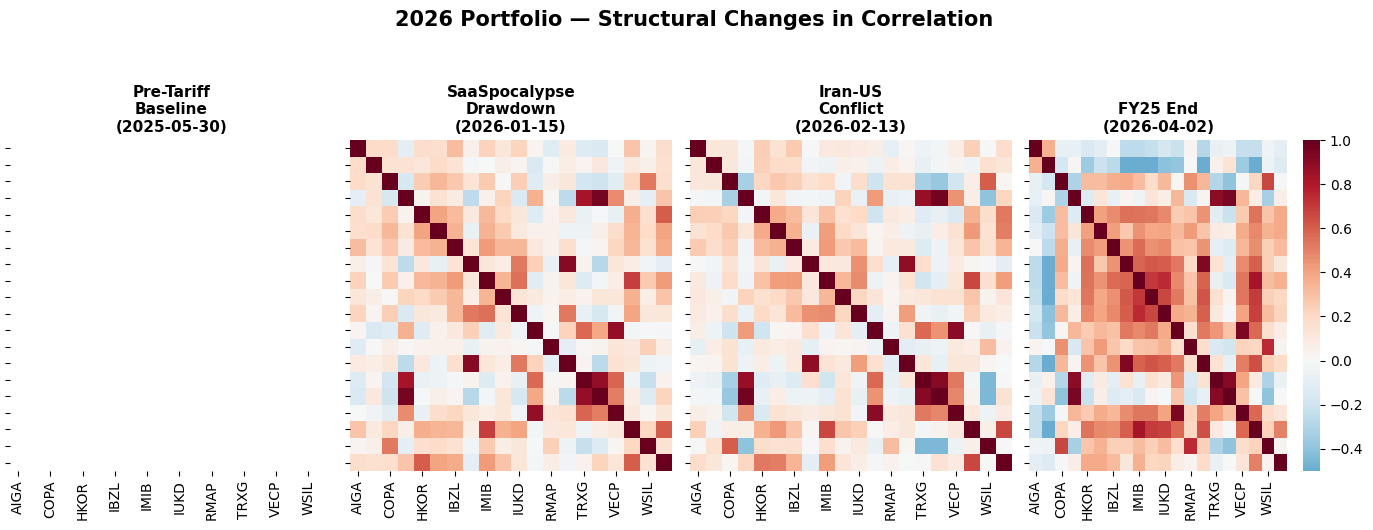


Key insight: during equity-stress windows, metals/commodities (SPLT,
SSLN, COMG, CXAP) exhibit low or negative correlation with the equity
block — providing rebalancing dry powder.


In [11]:
portfolio_26 = load_portfolio(year=2026)
tickers_26 = sorted(portfolio_26['ticker'].unique().tolist())
print(f"2026 portfolio tickers ({len(tickers_26)}): {tickers_26}")

price_data_26 = {}
for t in tickers_26:
    try:
        price_data_26[t] = provider.get_historical_prices(t)
    except Exception as exc:
        print(f"  Warning: {t}: {exc}")

close_df_26 = pd.DataFrame(
    {t: df['close'] for t, df in price_data_26.items() if 'close' in df.columns}
).dropna(axis=1, how='all').loc[FY25_START:FY25_END].dropna()

daily_ret_26 = close_df_26.pct_change().dropna()
rolling_corr_26 = daily_ret_26.rolling(window=90).corr()
available_26 = rolling_corr_26.index.get_level_values(0).unique()

snap26 = {
    'Pre-Tariff\nBaseline':  '2025-06-01',
    'SaaSpocalypse\nDrawdown': '2026-01-15',
    'Iran-US\nConflict':       '2026-02-15',
    'FY25 End':                str(FY25_END.date()),
}

fig, axes = plt.subplots(1, len(snap26), figsize=(14, 5), sharey=True)
for i, (name, date_str) in enumerate(snap26.items()):
    target = pd.to_datetime(date_str)
    eligible = available_26[available_26 <= target]
    if len(eligible) == 0:
        axes[i].set_visible(False)
        continue
    nearest = eligible[-1]
    sns.heatmap(rolling_corr_26.loc[nearest], annot=False, cmap='RdBu_r',
                center=0, vmin=-0.5, vmax=1, ax=axes[i],
                cbar=(i == len(snap26) - 1))
    axes[i].set_title(f"{name}\n({nearest.strftime('%Y-%m-%d')})",
                      fontsize=11, fontweight='bold')
    if i > 0:
        axes[i].set_yticklabels([])
plt.suptitle('2026 Portfolio — Structural Changes in Correlation',
             fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()
print("\nKey insight: during equity-stress windows, metals/commodities (SPLT,")
print("SSLN, COMG, CXAP) exhibit low or negative correlation with the equity")
print("block — providing rebalancing dry powder.")


### 2.2 2026 Portfolio: Rebalancing Frequency Counterfactual

How would the 2026 portfolio have performed under different maintenance regimes
across the FY25 window?

- **Buy & Hold** — invest at target weights once, then do nothing.
- **Monthly (~22 rebalances)** — back to target weights ~every business month.
- **Bi-weekly (~44 rebalances)** — every two weeks.


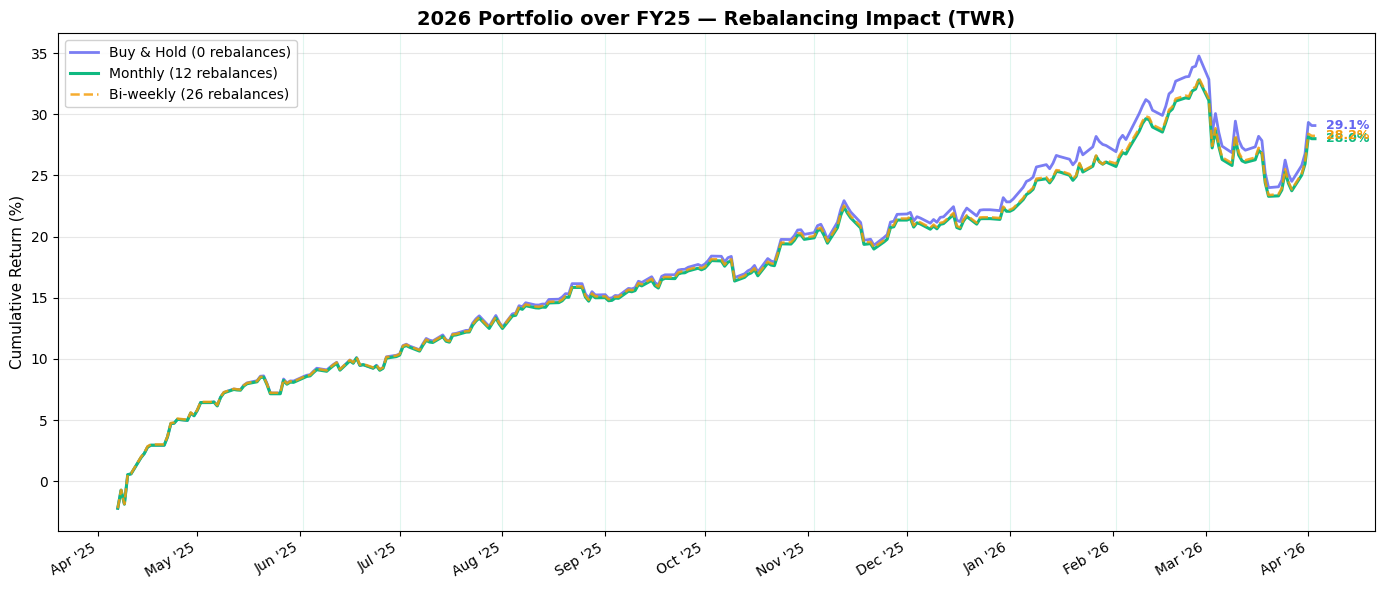


Final Cumulative Returns (TWR) — 2026 Portfolio over FY25:
  Buy & Hold:                       29.08%
  Monthly (12 rebalances):     28.00%
  Bi-weekly (26 rebalances):   28.24%


In [12]:
bt26 = Backtester(price_data_26, FY25_START, FY25_END)

weight_map = dict(zip(portfolio_26['ticker'], portfolio_26['final_cash_weights']))
total_w = sum(weight_map.values())
target_weights_26 = {
    t: w / total_w for t, w in weight_map.items() if t in price_data_26
}

initial_capital = 20_000.0
bnh_holdings_26 = {}
bnh_cost_26 = 0.0
for tkr, w in target_weights_26.items():
    alloc = initial_capital * w
    px = bt26.get_price(tkr, FY25_START)
    if px and px > 0:
        bnh_holdings_26[tkr] = alloc / px
        bnh_cost_26 += alloc

bnh_twr_26 = bt26.run_buy_and_hold_series(bnh_holdings_26)

monthly_dates = pd.bdate_range(FY25_START, FY25_END, freq='BMS').tolist()
if monthly_dates and monthly_dates[0] < FY25_START:
    monthly_dates[0] = FY25_START
monthly_twr_26 = bt26.run_simulated_rebalance(
    bnh_holdings_26, target_weights_26, monthly_dates
)

biweekly_dates = pd.bdate_range(FY25_START, FY25_END, freq='10B').tolist()
if biweekly_dates and biweekly_dates[0] < FY25_START:
    biweekly_dates[0] = FY25_START
biweekly_twr_26 = bt26.run_simulated_rebalance(
    bnh_holdings_26, target_weights_26, biweekly_dates
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(bt26.all_dates, bnh_twr_26, label='Buy & Hold (0 rebalances)',
        color='#6366f1', linewidth=2, alpha=0.85)
ax.plot(bt26.all_dates, monthly_twr_26,
        label=f'Monthly ({len(monthly_dates)} rebalances)',
        color='#10b981', linewidth=2.2)
ax.plot(bt26.all_dates, biweekly_twr_26,
        label=f'Bi-weekly ({len(biweekly_dates)} rebalances)',
        color='#f59e0b', linewidth=1.8, linestyle='--', alpha=0.85)
for rd in monthly_dates[1:]:
    ax.axvline(rd, color='#10b981', alpha=0.12, linewidth=0.8)
ax.set_title('2026 Portfolio over FY25 — Rebalancing Impact (TWR)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Cumulative Return (%)', fontsize=11)
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax.grid(axis='y', alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate(rotation=30)
for label, series, color in [
    ('B&H', bnh_twr_26, '#6366f1'),
    ('Monthly', monthly_twr_26, '#10b981'),
    ('Bi-wkly', biweekly_twr_26, '#f59e0b'),
]:
    if series is not None and len(series) > 0:
        ax.annotate(f'{series.iloc[-1]:.1f}%',
                    xy=(bt26.all_dates[-1], series.iloc[-1]),
                    xytext=(8, 0), textcoords='offset points',
                    fontsize=9, fontweight='bold', color=color, va='center')
plt.tight_layout()
plt.show()

print(f"\nFinal Cumulative Returns (TWR) — 2026 Portfolio over FY25:")
print(f"  Buy & Hold:                       {bnh_twr_26.iloc[-1]:.2f}%")
print(f"  Monthly ({len(monthly_dates)} rebalances):     "
      f"{monthly_twr_26.iloc[-1]:.2f}%")
print(f"  Bi-weekly ({len(biweekly_dates)} rebalances):   "
      f"{biweekly_twr_26.iloc[-1]:.2f}%")


### 2.3 Regime Comparison: 2025 vs 2026 Portfolios

Both portfolios are evaluated over the FY25 window using their target weights,
with **dynamic per-day weight renormalisation** (so 2026-only tickers that
list mid-window contribute zero to early-period returns and nothing else gets
diluted by their absence).


In [13]:
raw_w25 = dict(zip(portfolio_25['ticker'], portfolio_25['final_cash_weights']))
raw_w26 = dict(zip(portfolio_26['ticker'], portfolio_26['final_cash_weights']))

union_tickers = sorted(set(list(raw_w25) + list(raw_w26)))
union_prices = {}
for t in union_tickers:
    try:
        union_prices[t] = provider.get_historical_prices(t)
    except Exception as exc:
        print(f"  Warning: {t}: {exc}")

close_union = pd.DataFrame(
    {t: df['close'] for t, df in union_prices.items() if 'close' in df.columns}
).dropna(axis=1, how='all').loc[FY25_START:FY25_END]

available = set(close_union.columns)
raw_w25 = {t: w for t, w in raw_w25.items() if t in available}
raw_w26 = {t: w for t, w in raw_w26.items() if t in available}

daily_ret = close_union.pct_change()

port_ret_25 = dynamic_portfolio_return(daily_ret, raw_w25)
port_ret_26 = dynamic_portfolio_return(daily_ret, raw_w26)

s25 = sum(raw_w25.values()); weights_25 = {t: w / s25 for t, w in raw_w25.items()}
s26 = sum(raw_w26.values()); weights_26 = {t: w / s26 for t, w in raw_w26.items()}

cum_ret_25 = (1 + port_ret_25).cumprod() - 1
cum_ret_26 = (1 + port_ret_26).cumprod() - 1

WINDOW = 30  # shared rolling window for downstream cells

print(f"2025 portfolio: {len(raw_w25)} tickers — {sorted(raw_w25.keys())}")
print(f"2026 portfolio: {len(raw_w26)} tickers — {sorted(raw_w26.keys())}")
print(f"Window: {close_union.index.min().date()} → "
      f"{close_union.index.max().date()}  ({len(close_union)} trading days)")
for t in sorted(raw_w26):
    first_valid = close_union[t].first_valid_index()
    if first_valid and first_valid > FY25_START + pd.Timedelta(days=5):
        print(f"  {t}: data starts {first_valid.date()} "
              f"(dynamically excluded before this date)")


2025 portfolio: 16 tickers — ['AUAD', 'EMCP', 'HMCH', 'IBZL', 'IGLT', 'IMIB', 'LCUK', 'PRIJ', 'PRIR', 'QYLP', 'SLXX', 'TRXG', 'UC81', 'VECP', 'VEMT', 'XDDX']
2026 portfolio: 20 tickers — ['AIGA', 'AIGE', 'COPA', 'EMCP', 'HKOR', 'HMCH', 'IBZL', 'IGLT', 'IMIB', 'ISJP', 'IUKD', 'PRIR', 'RMAP', 'SLXX', 'TRXG', 'UC81', 'VECP', 'VGER', 'WSIL', 'XSTC']
Window: 2025-04-07 → 2026-04-02  (251 trading days)


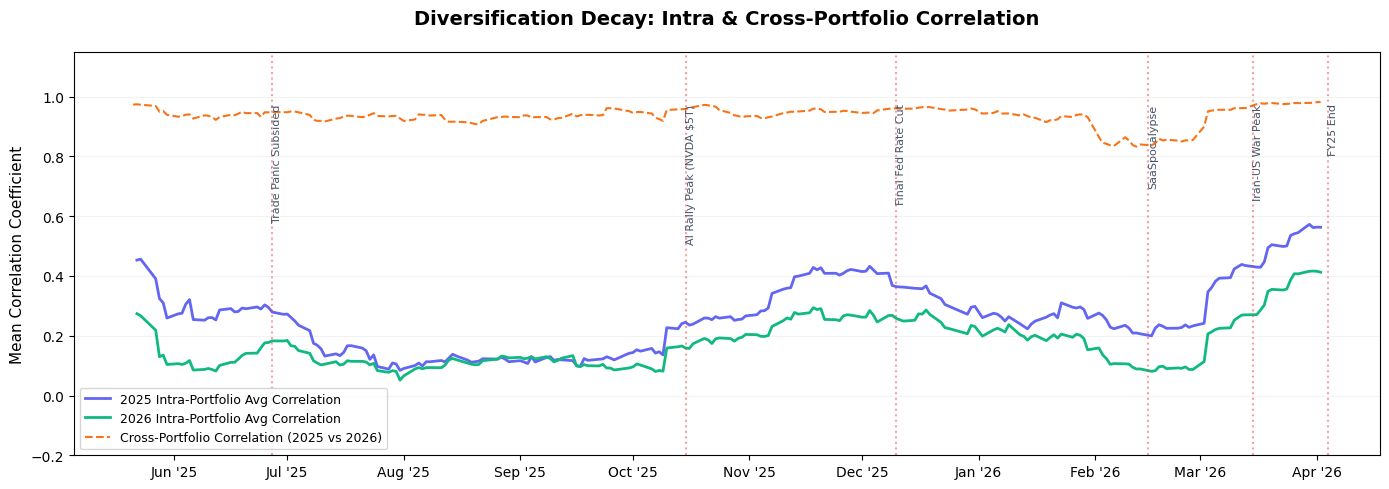

2025 intra — median: 0.259,  min: 0.084
2026 intra — median: 0.159,  min: 0.052
Cross      — median: 0.939


In [14]:
avg_corr_25 = rolling_avg_pairwise_corr(daily_ret[list(weights_25.keys())], WINDOW)
avg_corr_26 = rolling_avg_pairwise_corr(daily_ret[list(weights_26.keys())], WINDOW)
cross_corr  = port_ret_25.rolling(WINDOW).corr(port_ret_26)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(avg_corr_25.index, avg_corr_25, color='#6366f1', linewidth=2,
        label='2025 Intra-Portfolio Avg Correlation')
ax.plot(avg_corr_26.index, avg_corr_26, color='#10b981', linewidth=2,
        label='2026 Intra-Portfolio Avg Correlation')
ax.plot(cross_corr.index, cross_corr, color='#f97316', linewidth=1.5,
        linestyle='--', label='Cross-Portfolio Correlation (2025 vs 2026)')
for name, date_str in timeline.items():
    dt = pd.to_datetime(date_str)
    if dt >= avg_corr_25.dropna().index.min():
        ax.axvline(dt, color='#ef4444', linestyle=':', alpha=0.5)
        ax.text(dt, ax.get_ylim()[1] * 0.95, name, rotation=90,
                verticalalignment='top', fontsize=8, color='#475569')
ax.set_title('Diversification Decay: Intra & Cross-Portfolio Correlation',
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Mean Correlation Coefficient', fontsize=11)
ax.set_ylim(-0.2, 1.15)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.grid(axis='y', alpha=0.15)
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout()
plt.show()

print(f"2025 intra — median: {avg_corr_25.median():.3f},  min: {avg_corr_25.min():.3f}")
print(f"2026 intra — median: {avg_corr_26.median():.3f},  min: {avg_corr_26.min():.3f}")
print(f"Cross      — median: {cross_corr.median():.3f}")


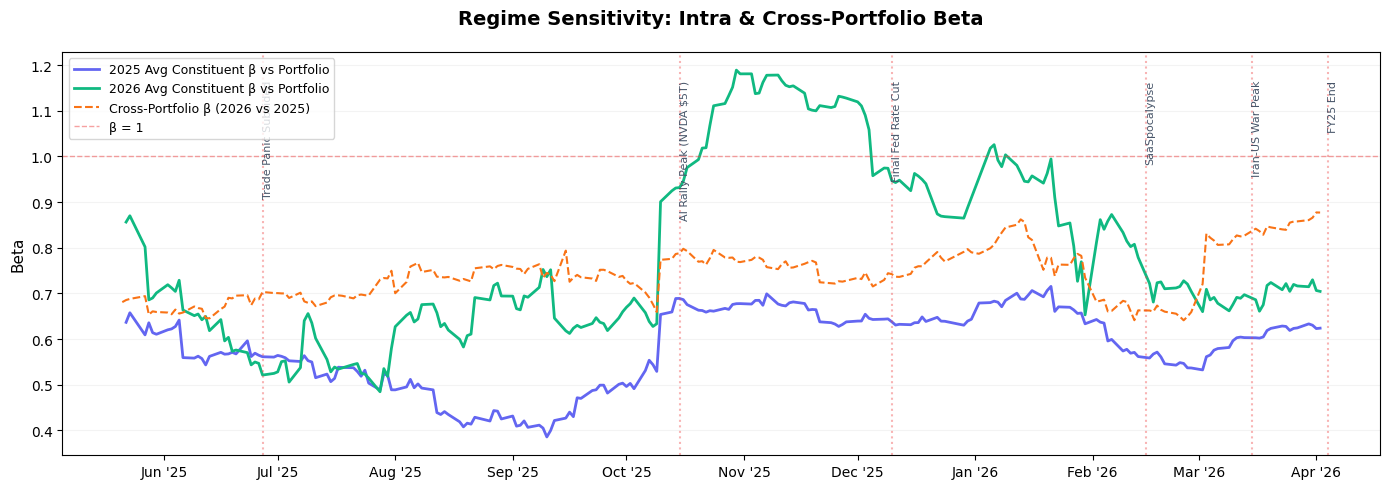

2025 avg constituent β — median: 0.596
2026 avg constituent β — median: 0.713
Cross-portfolio β     — median: 0.738


In [15]:
avg_beta_25 = rolling_constituent_beta(
    daily_ret[list(weights_25.keys())], port_ret_25, WINDOW
)
avg_beta_26 = rolling_constituent_beta(
    daily_ret[list(weights_26.keys())], port_ret_26, WINDOW
)
cross_cov  = port_ret_26.rolling(WINDOW).cov(port_ret_25)
cross_var  = port_ret_25.rolling(WINDOW).var()
cross_beta = (cross_cov / cross_var).clip(-3, 3)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(avg_beta_25.index, avg_beta_25, color='#6366f1', linewidth=2,
        label='2025 Avg Constituent β vs Portfolio')
ax.plot(avg_beta_26.index, avg_beta_26, color='#10b981', linewidth=2,
        label='2026 Avg Constituent β vs Portfolio')
ax.plot(cross_beta.index, cross_beta, color='#f97316', linewidth=1.5,
        linestyle='--', label='Cross-Portfolio β (2026 vs 2025)')
ax.axhline(1.0, color='#ef4444', linestyle='--', alpha=0.5, linewidth=1,
           label='β = 1')
for name, date_str in timeline.items():
    dt = pd.to_datetime(date_str)
    if dt >= avg_beta_25.dropna().index.min():
        ax.axvline(dt, color='#ef4444', linestyle=':', alpha=0.4)
        ax.text(dt, ax.get_ylim()[1] * 0.95, name, rotation=90,
                verticalalignment='top', fontsize=8, color='#475569')
ax.set_title('Regime Sensitivity: Intra & Cross-Portfolio Beta',
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Beta', fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.grid(axis='y', alpha=0.15)
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print(f"2025 avg constituent β — median: {avg_beta_25.median():.3f}")
print(f"2026 avg constituent β — median: {avg_beta_26.median():.3f}")
print(f"Cross-portfolio β     — median: {cross_beta.median():.3f}")


In [16]:
period_df = period_metrics_table(
    port_ret_25, port_ret_26, timeline,
    label_a='2025', label_b='2026',
)

def _colour_neg(val):
    if val is None or (isinstance(val, float) and val != val):
        return ''
    return 'color: #dc2626; font-weight: bold' if val < 0 else ''

def _colour_excess(val):
    colour = '#16a34a' if val > 0 else '#dc2626' if val < 0 else '#000'
    return f'color: {colour}; font-weight: bold'

styled = (period_df.style
    .format({
        'Days': '{:.0f}',
        'Return 2025 (%)': '{:+.2f}',
        'Return 2026 (%)': '{:+.2f}',
        'Excess (%)': '{:+.2f}',
        'Vol 2025 (ann.)': '{:.2f}',
        'Vol 2026 (ann.)': '{:.2f}',
        'Correlation': '{:.3f}',
        'Beta': '{:.3f}',
    })
    .map(_colour_neg, subset=['Return 2025 (%)', 'Return 2026 (%)', 'Beta'])
    .map(_colour_excess, subset=['Excess (%)'])
    .set_caption('Period-by-Period Regime Metrics: 2025 vs 2026 Portfolio'))
styled

,Days,Return 2025 (%),Return 2026 (%),Excess (%),Vol 2025 (ann.),Vol 2026 (ann.),Correlation,Beta
Period,,,,,,,,
Liberation Day (Tariffs) → Tariff Walkback,24,+13.75,+9.89,-3.86,15.93,11.20,0.973,0.684
Tariff Walkback → Trade Panic Subsided,33,+1.65,+2.39,+0.74,8.09,5.99,0.936,0.693
Trade Panic Subsided → AI Rally Peak (NVDA $5T),78,+6.84,+7.02,+0.18,6.85,5.60,0.947,0.774
AI Rally Peak (NVDA $5T) → Final Fed Rate Cut,41,+2.29,+3.29,+0.99,9.69,7.51,0.945,0.732
Final Fed Rate Cut → SaaSpocalypse,45,+6.21,+6.75,+0.55,7.86,6.49,0.882,0.728
SaaSpocalypse → Iran-US War Peak,20,-2.73,-2.26,+0.47,18.97,16.31,0.984,0.846
Iran-US War Peak → FY25 End,14,+1.72,+1.60,-0.13,16.60,15.61,0.976,0.918


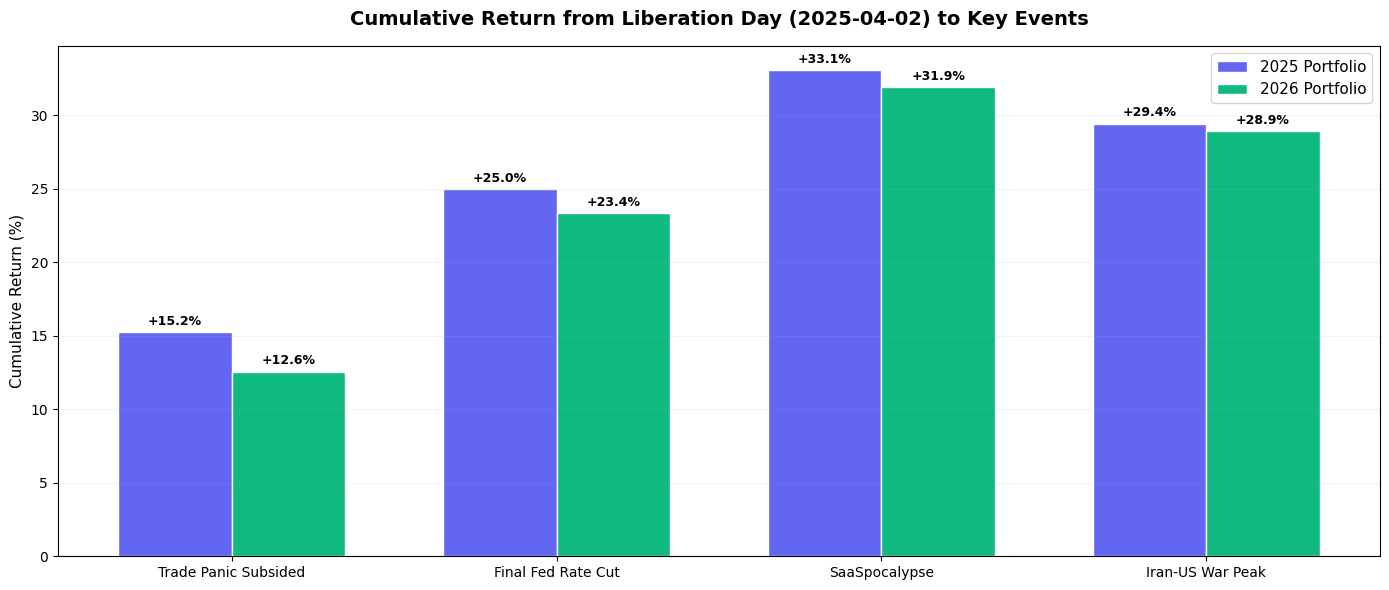

In [17]:
base_date = pd.to_datetime(timeline['Liberation Day (Tariffs)'])
snap_labels, snap_25, snap_26 = [], [], []
for ev in snapshot_events:
    ev_date = pd.to_datetime(timeline[ev])
    r25 = port_ret_25.loc[base_date:ev_date]
    r26 = port_ret_26.loc[base_date:ev_date]
    if len(r25) < 2:
        continue
    snap_labels.append(ev)
    snap_25.append(((1 + r25).cumprod().iloc[-1] - 1) * 100)
    snap_26.append(((1 + r26).cumprod().iloc[-1] - 1) * 100)

x = np.arange(len(snap_labels))
width = 0.35
fig, ax = plt.subplots(figsize=(14, 6))
bars_25 = ax.bar(x - width / 2, snap_25, width, label='2025 Portfolio',
                 color='#6366f1', edgecolor='white')
bars_26 = ax.bar(x + width / 2, snap_26, width, label='2026 Portfolio',
                 color='#10b981', edgecolor='white')
for bars in [bars_25, bars_26]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2,
                h + (0.3 if h >= 0 else -0.6),
                f'{h:+.1f}%', ha='center',
                va='bottom' if h >= 0 else 'top',
                fontsize=9, fontweight='bold')
ax.axhline(0, color='#94a3b8', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(snap_labels, fontsize=10)
ax.set_ylabel('Cumulative Return (%)', fontsize=11)
ax.set_title(f'Cumulative Return from Liberation Day '
             f'({base_date.date()}) to Key Events',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.15)
plt.tight_layout()
plt.show()


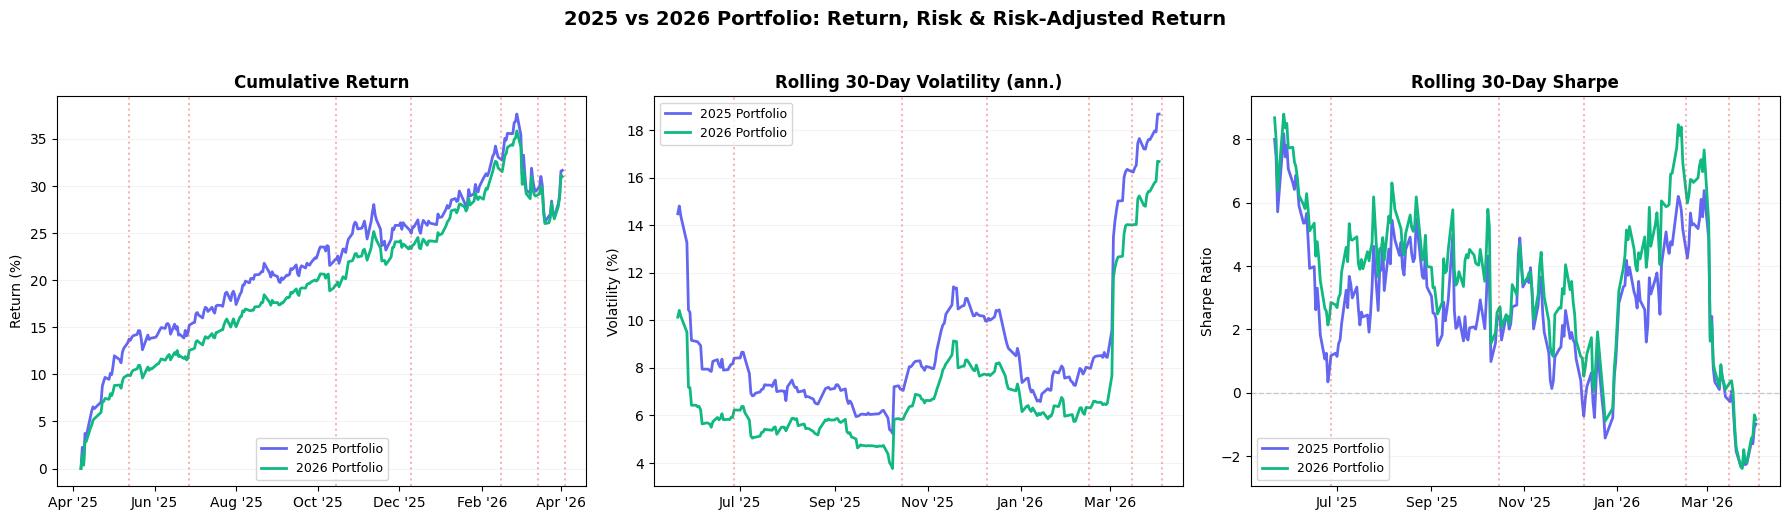

FY25 summary (2025-04-07 to 2026-04-02):
  2025 — Return: +31.67%   Vol: 10.92%   Sharpe: 2.912
  2026 — Return: +31.00%   Vol: 8.82%   Sharpe: 3.530


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(cum_ret_25.index, cum_ret_25 * 100, color='#6366f1',
             linewidth=2, label='2025 Portfolio')
axes[0].plot(cum_ret_26.index, cum_ret_26 * 100, color='#10b981',
             linewidth=2, label='2026 Portfolio')
for name, date_str in timeline.items():
    dt = pd.to_datetime(date_str)
    if dt >= cum_ret_25.index.min():
        axes[0].axvline(dt, color='#ef4444', linestyle=':', alpha=0.4)
axes[0].set_title('Cumulative Return', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Return (%)', fontsize=10)
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.15)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

roll_vol_25 = port_ret_25.rolling(WINDOW).std() * np.sqrt(252) * 100
roll_vol_26 = port_ret_26.rolling(WINDOW).std() * np.sqrt(252) * 100
axes[1].plot(roll_vol_25.index, roll_vol_25, color='#6366f1', linewidth=2,
             label='2025 Portfolio')
axes[1].plot(roll_vol_26.index, roll_vol_26, color='#10b981', linewidth=2,
             label='2026 Portfolio')
for name, date_str in timeline.items():
    dt = pd.to_datetime(date_str)
    if dt >= roll_vol_25.dropna().index.min():
        axes[1].axvline(dt, color='#ef4444', linestyle=':', alpha=0.4)
axes[1].set_title('Rolling 30-Day Volatility (ann.)', fontsize=12,
                  fontweight='bold')
axes[1].set_ylabel('Volatility (%)', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.15)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

roll_sharpe_25 = rolling_sharpe(port_ret_25, window=WINDOW)
roll_sharpe_26 = rolling_sharpe(port_ret_26, window=WINDOW)
axes[2].plot(roll_sharpe_25.index, roll_sharpe_25, color='#6366f1', linewidth=2,
             label='2025 Portfolio')
axes[2].plot(roll_sharpe_26.index, roll_sharpe_26, color='#10b981', linewidth=2,
             label='2026 Portfolio')
axes[2].axhline(0, color='#94a3b8', linestyle='--', alpha=0.5, linewidth=1)
for name, date_str in timeline.items():
    dt = pd.to_datetime(date_str)
    if dt >= roll_sharpe_25.dropna().index.min():
        axes[2].axvline(dt, color='#ef4444', linestyle=':', alpha=0.4)
axes[2].set_title('Rolling 30-Day Sharpe', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Sharpe Ratio', fontsize=10)
axes[2].legend(fontsize=9)
axes[2].grid(axis='y', alpha=0.15)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.suptitle('2025 vs 2026 Portfolio: Return, Risk & Risk-Adjusted Return',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

ann_ret_25 = cum_ret_25.iloc[-1] / (len(cum_ret_25) / 252)
ann_ret_26 = cum_ret_26.iloc[-1] / (len(cum_ret_26) / 252)
ann_vol_25 = port_ret_25.std() * np.sqrt(252)
ann_vol_26 = port_ret_26.std() * np.sqrt(252)
sharpe_25  = ann_ret_25 / ann_vol_25 if ann_vol_25 > 0 else np.nan
sharpe_26  = ann_ret_26 / ann_vol_26 if ann_vol_26 > 0 else np.nan
print(f"FY25 summary ({close_union.index.min().date()} to "
      f"{close_union.index.max().date()}):")
print(f"  2025 — Return: {cum_ret_25.iloc[-1]*100:+.2f}%   "
      f"Vol: {ann_vol_25*100:.2f}%   Sharpe: {sharpe_25:.3f}")
print(f"  2026 — Return: {cum_ret_26.iloc[-1]*100:+.2f}%   "
      f"Vol: {ann_vol_26*100:.2f}%   Sharpe: {sharpe_26:.3f}")


## 3. What This Analysis Does NOT Include

This backtest is built for a DIY UK ISA investor; it is **not audit-grade**.
The following items are deliberately excluded:

- **Beyond-TER fees** — platform fees (InvestEngine and Trading212 are free
  for ETFs at the time of writing), broker spreads, stamp duty (most ETFs
  exempt), slippage. **Fund TER itself is already embedded in the price
  series** — see methodology.
- **Tracking difference vs underlying index** — the rigorous fund-efficiency
  measure (bundles TER, securities lending, sampling drag, tax withholding
  into one number). On the roadmap.
- **Forward-looking claims** — past TWR, Sharpe, beta, drawdown are all
  historical; none of these are predictions.
- **Survivorship & left-censoring** — JustETF universe is *today's* universe;
  closed/merged funds are not represented. Each ETF's history starts at its
  launch date.
- **FX decomposition** — unhedged-fund GBP returns include currency exposure
  but it is not isolated as a separate factor.

### Future metrics (on the roadmap)

See [Methodology → Future Work](../content/00b_methodology.md#future-work):

- **XIRR / Money-Weighted Return** — the IRR of actual cash flows; pairs with
  TWR for the investor-experience view.
- **Sortino Ratio** — Sharpe but penalising downside deviation only.
- **Calmar Ratio** — return ÷ |max drawdown|.
- **Factor attribution** — value / growth / size / momentum (Fama–French).
- **Tracking difference vs index** — supersedes comparing TER alone; needs
  raw benchmark-index total-return series.


## 4. Appendix — Data Quality & Coverage Check (2025 Portfolio)

Sanity check for the FY25 window: every 2025-portfolio ticker needs price data covering 2025-04-05 → 2026-04-04. Stale or partial coverage here would invalidate the TWR / Sharpe / benchmark figures above. Reviewed last because failures invalidate the backtest — easier to spot once you know what the numbers looked like.

In [19]:
tickers_25 = sorted(portfolio_25['ticker'].unique().tolist())

_price_data = {}
_fetch_errors = []
for t in tickers_25:
    try:
        _price_data[t] = provider.get_historical_prices(t)
    except Exception as exc:
        _fetch_errors.append((t, str(exc)))

rows = []
for t in tickers_25:
    if t not in _price_data or 'close' not in _price_data[t].columns:
        rows.append({
            'Ticker': t, 'First Date': None, 'Last Date': None,
            'Trading Days': 0, 'Missing Days': FY25_BDAYS,
            'Gap %': 100.0, 'Last Price': None, 'Stale': True,
        })
        continue

    close = _price_data[t]['close'].dropna()
    if close.empty:
        rows.append({
            'Ticker': t, 'First Date': None, 'Last Date': None,
            'Trading Days': 0, 'Missing Days': FY25_BDAYS,
            'Gap %': 100.0, 'Last Price': None, 'Stale': True,
        })
        continue

    close_fy = close.loc[FY25_START:FY25_END]
    actual = len(close_fy)
    missing = FY25_BDAYS - actual
    gap_pct = missing / FY25_BDAYS * 100 if FY25_BDAYS > 0 else 0
    last = close.index.max()
    rows.append({
        'Ticker': t,
        'First Date': close.index.min().date(),
        'Last Date': last.date(),
        'Trading Days': actual,
        'Missing Days': missing,
        'Gap %': gap_pct,
        'Last Price': close.iloc[-1],
        'Stale': (FY25_END - last).days > 5,
    })

quality_df = pd.DataFrame(rows).set_index('Ticker')

def _flag_gaps(val):
    if pd.isna(val): return ''
    if val > 5: return 'color: #dc2626; font-weight: bold'
    if val > 1: return 'color: #f97316'
    return 'color: #16a34a'

def _flag_stale(val):
    return 'background-color: #fef2f2; color: #dc2626; font-weight: bold' if val else ''

styled = (quality_df.style
    .format({
        'Trading Days': '{:.0f}',
        'Missing Days': lambda v: f'{v:.0f}' if pd.notna(v) else '-',
        'Gap %': lambda v: f'{v:.1f}%' if pd.notna(v) else '-',
        'Last Price': lambda v: f'£{v:.2f}' if pd.notna(v) else '-',
    })
    .map(_flag_gaps, subset=['Gap %'])
    .map(_flag_stale, subset=['Stale'])
    .set_caption(
        f'2025 Portfolio Data Quality — FY25 window '
        f'({FY25_START.date()} to {FY25_END.date()}, {FY25_BDAYS} business days). '
        f'Stale = last data point > 5 days before FY25 end.'
    ))
display(styled)

print(f'Tickers: {len(tickers_25)} total, {len(_price_data)} fetched.')
for t, err in _fetch_errors:
    print(f'  FETCH ERROR: {t} — {err}')
print(f'Perfect coverage: {(quality_df["Missing Days"] == 0).sum()}/{len(tickers_25)}')
print(f'Stale (>5 days):  {quality_df["Stale"].sum()}')

del _price_data, _fetch_errors


,First Date,Last Date,Trading Days,Missing Days,Gap %,Last Price,Stale
Ticker,,,,,,,
AUAD,2018-01-08,2026-04-17,248,12,4.6%,£21.65,False
EMCP,2012-04-19,2026-04-17,251,9,3.5%,£66.86,False
HMCH,2011-01-28,2026-04-17,251,9,3.5%,£6.04,False
IBZL,2005-11-21,2026-04-17,251,9,3.5%,£24.67,False
IGLT,2006-12-04,2026-04-17,251,9,3.5%,£9.88,False
IMIB,2007-07-12,2026-04-17,251,9,3.5%,£25.80,False
LCUK,2018-03-22,2026-04-17,251,9,3.5%,£14.95,False
PRIJ,2019-03-14,2026-04-17,251,9,3.5%,£30.05,False
PRIR,2019-04-16,2026-04-17,237,23,8.8%,£14.77,False


Tickers: 16 total, 16 fetched.
Perfect coverage: 0/16
Stale (>5 days):  0
